# JARVIS — Checkpoint 1: el router que decide qué cerebros piensan
**SI3003 Inteligencia Artificial · EAFIT · Nicolás Rodríguez**

JARVIS es mi asistente personal: varios modelos de lenguaje ("cerebros") que funcionan como **una sola IA**. Para cada petición, un **router** decide quién entra al *consejo* que la resuelve. Usar siempre la nube es caro, gasta cuota y saca datos del computador. Usar siempre el modelo local es gratis y privado, pero se equivoca en ciertas tareas. El problema de la Parte 1 es **decidir, petición por petición, a qué cerebro enviarla**.

| Pieza | Técnica del curso | Dónde |
|---|---|---|
| Intención de la petición | **Naive Bayes** multinomial desde cero (sem. 7) | `jarvis/router/features.py` |
| Dificultad | **Árbol de decisión** de un nivel por categoría (sem. 6) | `jarvis/router/features.py` |
| Datos privados | Reglas + Naive Bayes con margen (prioriza *recall*) | `jarvis/router/features.py` |
| Formulación | **MDP** con presupuesto diario (sem. 4) | `jarvis/router/env.py` |
| Política | **Q-learning** tabular ε-greedy con escudo de privacidad (sem. 5) | `jarvis/router/qlearning.py` |

**Criterio cuantitativo** (se verifica automáticamente al final):
1. calidad **≥ 95 %** de la mejor política *permitida*, "nube siempre, salvo lo privado" ("siempre nube" sin filtro saca datos privados, así que no es una opción real, aunque también se reporta);
2. usar la nube en **≤ 60 %** de las peticiones (ahorro de costo y cuota ≥ 40 %);
3. **0 fugas** de datos privados.

**Protocolo.** La evaluación es **de punta a punta**: el router decide con lo que *predice* la percepción (no con las etiquetas reales) y las fugas se cuentan con la etiqueta real. Los hiperparámetros se eligen en validación y el test se usa una sola vez. Además hay un **banco oculto** de 42 tareas nuevas (§8) y un script para evaluar el router congelado sobre cualquier banco (`bench/evaluar_router.py`).

**Reproducir:** `python -m pytest -q` (validación del calificador y del router) y luego ejecutar este notebook de arriba abajo (~1 min, sin llamadas a APIs: usa los resultados guardados en `data/`).

In [1]:
import json, random, sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from jarvis.router.env import RouterEnv
from jarvis.router.qlearning import QRouter, evaluate
from jarvis.router.features import Perception
from jarvis.router.evaluation import load_priced, compare, check, dias, EPISODIO
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
random.seed(0); np.random.seed(0)
BRAINS = ["local", "gemini"]

## 1. Datos: un banco real, no simulado

Construí un banco de **86 tareas verificables** en 6 categorías (`bench/tasks.jsonl`). La calificación es automática: las respuestas de matemáticas se calculan en el propio generador, el código se califica **ejecutando tests** y la extracción se compara campo a campo. El calificador está validado con una solución de referencia por cada tarea de código (`tests/`).

Cada tarea se corrió **de verdad** en cada cerebro disponible:
- **local**: `qwen3:4b-instruct` vía Ollama en mi Mac (gratis, privado);
- **gemini**: `gemini-3.5-flash` vía API (nube).

Claude, GPT y Grok están integrados en JARVIS, pero sus cuentas de API todavía no tienen saldo. Cuando lo tengan, basta con correr el banco con ellos y volver a ejecutar este notebook.

In [2]:
raw = pd.DataFrame(map(json.loads, open(ROOT / "data" / "results.jsonl")))
df = raw[raw.error.isna() & raw.brain.isin(BRAINS)]
print(f"{df.task_id.nunique()} tareas × {df.brain.nunique()} cerebros = {len(df)} ejecuciones reales")
resumen = df.pivot_table(index=["category", "difficulty"], columns="brain", values="score", aggfunc="mean")
resumen.loc[("TOTAL", ""), :] = df.groupby("brain").score.mean()
resumen.round(2)

86 tareas × 2 cerebros = 172 ejecuciones reales


brain                   gemini  local
category    difficulty               
codigo      easy          1.00   1.00
            hard          1.00   1.00
extraccion  easy          1.00   1.00
            hard          1.00   1.00
formato     easy          1.00   0.75
            hard          1.00   1.00
hechos      easy          1.00   1.00
            hard          1.00   1.00
matematicas easy          1.00   0.50
            hard          0.94   0.19
privado     easy          0.75   0.75
            hard          1.00   1.00
TOTAL                     0.98   0.72

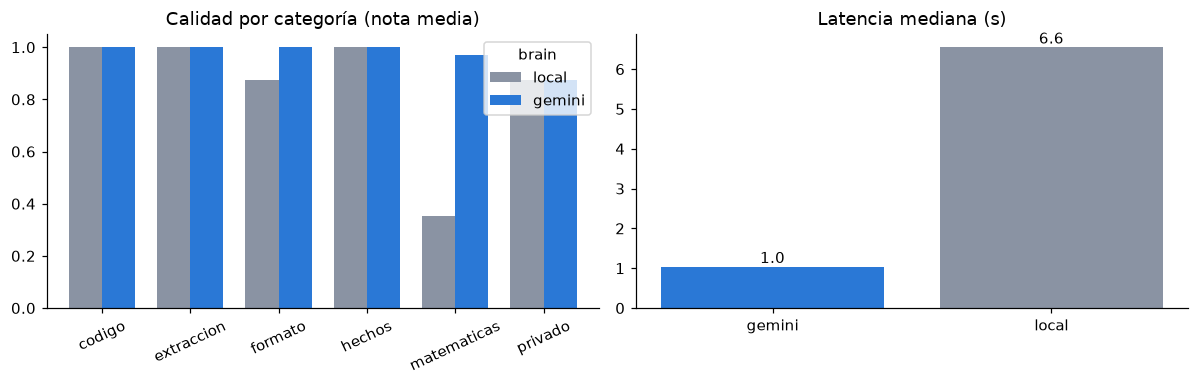

In [3]:
lat = df.groupby("brain").latency_s.median()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
cat = df.pivot_table(index="category", columns="brain", values="score", aggfunc="mean")[BRAINS]
cat.plot.bar(ax=ax[0], color=["#8a93a3", "#2a78d6"], width=.75)
ax[0].set_title("Calidad por categoría (nota media)"); ax[0].set_ylim(0, 1.05); ax[0].set_xlabel(""); ax[0].tick_params(axis="x", rotation=25)
ax[1].bar(lat.index, lat.values, color=["#2a78d6" if b == "gemini" else "#8a93a3" for b in lat.index])
ax[1].set_title("Latencia mediana (s)")
for i, v in enumerate(lat.values): ax[1].text(i, v, f"{v:.1f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

**Lectura.** El modelo local empata con la nube en código, extracción y hechos, pero **se cae en matemáticas** (cae en la trampa del bate y la pelota, falla vueltos y porcentajes). Esa es la estructura que un router puede explotar: pagar la nube solo donde el local falla.

## 2. Percepción: qué ve el router de cada petición

Divido las tareas en entrenamiento y test (50/50, estratificado por categoría). Todo lo que sigue se ajusta **solo con entrenamiento**.

- **Intención**: Naive Bayes multinomial con suavizado de Laplace.
- **Dificultad**: un árbol de decisión de un nivel por categoría ("difícil" si el texto supera un umbral de longitud aprendido). En 20 particiones aleatorias acierta 73 %, contra 59 % de un Naive Bayes de dificultad y 62 % de un umbral fijo.
- **Privacidad**: reglas (cédulas, claves, saldos, cuentas, salario y montos personales, en español e inglés) **o** Naive Bayes, este último solo si gana por un margen de 4 nats. Si una petición es privada, su categoría es «privado».

In [4]:
tasks = [json.loads(l) for l in open(ROOT / "bench" / "tasks.jsonl")]
TASK = {t["id"]: t for t in tasks}
rng = random.Random(7)
by_cat = {}
for t in tasks: by_cat.setdefault(t["category"], []).append(t)
train, test = [], []
for c, ts in by_cat.items():
    ts = ts[:]; rng.shuffle(ts); k = len(ts) // 2
    train += ts[:k]; test += ts[k:]
ver = Perception(train)
pred = {t["id"]: ver(t["prompt"]) for t in test}
acc_cat = np.mean([pred[t["id"]][0] == t["category"] for t in test])
acc_dif = np.mean([pred[t["id"]][1] == t["difficulty"] for t in test])
print(f"Tareas de test: {len(test)} · intención: {acc_cat:.1%} · dificultad: {acc_dif:.1%}")
pd.crosstab(pd.Series([t["category"] for t in test], name="real"), pd.Series([pred[t["id"]][0] for t in test], name="predicha"))

Tareas de test: 43 · intención: 93.0% · dificultad: 65.1%


predicha,codigo,extraccion,formato,hechos,matematicas,privado
real,,,,,,
codigo,7,0,0,0,0,0
extraccion,0,5,0,0,0,0
formato,1,0,1,1,1,0
hechos,0,0,0,6,0,0
matematicas,0,0,0,0,17,0
privado,0,0,0,0,0,4


In [5]:
extra_priv = ["Mi contraseña del correo es Sol2026*, ¿es segura?", "Tengo 2.300.000 en mi cuenta de ahorros, ¿cuánto ahorro al mes si guardo 10 %?",
              "Mi número de cédula es 1034556677, llena este formulario", "Revisa mi historia clínica: glucosa 130 en ayunas",
              "My bank account number is 004512339876, is it safe to share?", "Mi sueldo es 3.400.000, ¿cuánto es el 30 %?"]
extra_pub = ["¿Qué es un proceso de decisión de Markov?", "Escribe un haiku sobre Medellín", "¿Cuánto es 45 por 12?",
             "Resume el paper Attention Is All You Need", "Explica en una frase qué es Bancolombia",
             "What is the capital of Portugal?", "Laura trabaja en Nequi como diseñadora; extrae su cargo"]
X = [t["prompt"] for t in test] + extra_priv + extra_pub
y = [t["private"] for t in test] + [True] * len(extra_priv) + [False] * len(extra_pub)
yhat = [ver(x)[2] for x in X]
tp = sum(a and b for a, b in zip(y, yhat)); fp = sum((not a) and b for a, b in zip(y, yhat)); fn = sum(a and not b for a, b in zip(y, yhat))
print(f"Privacidad ({len(X)} textos, {sum(y)} privados) — recall: {tp / (tp + fn):.0%} · precisión: {tp / (tp + fp):.0%} · "
      f"falsos negativos (fugas potenciales): {fn} · falsos positivos: {fp}")

Privacidad (56 textos, 10 privados) — recall: 100% · precisión: 100% · falsos negativos (fugas potenciales): 0 · falsos positivos: 0


El detector prioriza el **recall**: un falso positivo solo manda una petición inofensiva al modelo local, pero un falso negativo sacaría un dato sensible del computador. Además, el MDP tiene un **escudo**: en estados que la percepción marca como privados, la única acción legal es el cerebro local. Si el detector se equivoca, el escudo no se activa y la fuga **sí se cuenta** en la evaluación.

## 3. El MDP

Un episodio es **un día de JARVIS**: llegan $N=20$ peticiones y hay un presupuesto diario $B$.

- **Estado** $s=(\text{categoría},\ \text{dificultad},\ \text{privada},\ \text{nivel de presupuesto})$, las tres primeras según la percepción; presupuesto ∈ {agotado, bajo, medio, alto}.
- **Acciones** $a \in$ {local, gemini}.
- **Recompensa**

$$r(s,a)=\text{calidad}(a)-\lambda\,\frac{\text{costo}(a)}{\bar c}-\mu\,\frac{\text{latencia}(a)}{\tilde \ell},\qquad r=-2\ \text{si hay fuga},\quad r=-1\ \text{si no alcanza el presupuesto}$$

- **Transición**: el presupuesto baja con el costo real y llega la siguiente petición.

**Costo.** Gemini se usa hoy en plan gratuito, pero ese plan tiene **cuota diaria**, así que la nube es un recurso escaso. Para que el MDP sea realista le asigno a Gemini su **precio de lista** por token, calculado con los tokens reales de cada respuesta. El presupuesto es lo que vuelve el problema **secuencial** (γ > 0): gastar la nube en tareas fáciles temprano deja sin ella a las difíciles del final.

In [6]:
outcomes, meta = load_priced(ROOT / "data" / "results.jsonl", BRAINS)
train_ids = [t["id"] for t in train if t["id"] in meta]; test_ids = [t["id"] for t in test if t["id"] in meta]
costo_nube_dia = np.mean([outcomes[(i, "gemini")].cost for i in meta]) * EPISODIO
BUDGET = 0.6 * costo_nube_dia     # alcanza para ~60 % de las peticiones en la nube
print(f"Costo medio de un día 'siempre nube': ${costo_nube_dia:.5f} → presupuesto diario B = ${BUDGET:.5f}")

def make_env(ids, seed, lam, mu, observed=None):
    return RouterEnv(outcomes, meta, BRAINS, ids, episode_len=EPISODIO, daily_budget=BUDGET, lam=lam, mu=mu, seed=seed,
                     observed=observed)

def entrenar(ids, lam, mu, gamma, seed, observed, episodios=8000):
    # paso α = n(s,a)^-0.7 por par estado-acción (Robbins-Monro): converge pese a recompensas ruidosas
    ag = QRouter(BRAINS, gamma=gamma, eps=1.0, eps_min=0.05, eps_decay=0.9995, seed=seed, alpha_power=0.7)
    curva = ag.train(make_env(ids, seed, lam, mu, observed), episodes=episodios)
    return ag, curva

Costo medio de un día 'siempre nube': $0.00190 → presupuesto diario B = $0.00114


## 4. Selección de hiperparámetros (validación)

Separo el 30 % de las tareas de **entrenamiento** como validación y ajusto una percepción aparte solo con el 70 % restante. Para cada combinación de λ (peso del costo), μ (peso de la latencia) y γ (cuánto pesa el futuro del día) entreno **3 semillas** y mido en validación.

**Tasa de aprendizaje.** Cada estado agrupa tareas distintas, así que la recompensa de un mismo par (s, a) es ruidosa. Una primera versión con α constante (0.2) daba políticas muy distintas según la semilla: en 10 entrenamientos, la calidad bajaba hasta 89.5 % y el uso de nube variaba entre 18 % y 67 %. Por eso uso el paso decreciente $lpha = n(s,a)^{-0.7}$ (condición de Robbins-Monro, con la que Q-learning converge) y 8 000 episodios.

**Regla de selección** (la misma del criterio final): entre las combinaciones que en validación usan la nube ≤ 60 % y no tienen fugas, la de **mayor calidad**; en empate, la que menos nube usa. Si ninguna cumple, se aplica la misma regla a todas. El test no se toca.

In [7]:
rng_v = random.Random(11)
tr = train_ids[:]; rng_v.shuffle(tr)
k = int(len(tr) * 0.7); fit_ids, val_ids = tr[:k], tr[k:]
ver_fit = Perception([TASK[i] for i in fit_ids])
obs_fit = {i: ver_fit(TASK[i]["prompt"]) for i in fit_ids + val_ids}
val_dias = dias(val_ids, n=150, seed=5)
grid = []
for lam in [0.05, 0.1, 0.2, 0.3, 0.5]:
    for mu in [0.05, 0.15]:
        for gamma in [0.5, 0.9]:
            evs = []
            for seed in range(3):
                ag, _ = entrenar(fit_ids, lam, mu, gamma, seed, obs_fit, episodios=4000)
                evs.append(evaluate(ag, make_env(val_ids, 2, lam, mu, obs_fit), val_dias))
            grid.append({"λ": lam, "μ": mu, "γ": gamma, "calidad val": np.mean([e["calidad media"] for e in evs]),
                         "% nube val": np.mean([e["% nube"] for e in evs]), "fugas val": sum(e["fugas privadas"] for e in evs)})
g = pd.DataFrame(grid)
ok = g[(g["% nube val"] <= 0.60) & (g["fugas val"] == 0)]
best = (ok if len(ok) else g).sort_values(["calidad val", "% nube val"], ascending=[False, True]).iloc[0]
LAM, MU, GAMMA = float(best["λ"]), float(best["μ"]), float(best["γ"])
mat = lambda ids: np.mean([meta[i]["category"] == "matematicas" for i in ids])
print(f"{len(ok)}/{len(g)} combinaciones cumplen en validación · elegidos: λ={LAM}, μ={MU}, γ={GAMMA}")
print(f"Validación: {len(val_ids)} tareas, {mat(val_ids):.0%} de matemáticas (entrenamiento: {mat(fit_ids):.0%}, test: {mat(test_ids):.0%})")
g.sort_values(["calidad val", "% nube val"], ascending=[False, True]).head(8).round(3)

0/20 combinaciones cumplen en validación · elegidos: λ=0.2, μ=0.05, γ=0.5
Validación: 13 tareas, 31% de matemáticas (entrenamiento: 43%, test: 40%)


,λ,μ,γ,calidad val,% nube val,fugas val
8,0.2,0.05,0.5,0.924,0.629,0
9,0.2,0.05,0.9,0.924,0.629,0
12,0.3,0.05,0.5,0.924,0.629,0
14,0.3,0.15,0.5,0.924,0.629,0
16,0.5,0.05,0.5,0.924,0.629,0
17,0.5,0.05,0.9,0.924,0.629,0
18,0.5,0.15,0.5,0.924,0.629,0
19,0.5,0.15,0.9,0.924,0.629,0


**Lectura honesta.** La validación es muy pequeña (13 tareas, con una percepción ajustada con menos datos): todas las combinaciones empatan en calidad y ninguna baja de 60 % de nube *en validación*, así que la regla desempata por el menor uso de nube. Es una limitación del tamaño del banco; por eso el criterio final se exige en test sobre 10 semillas y, además, en el banco oculto.

## 5. Entrenamiento con Q-learning

$$Q(s,a) \leftarrow Q(s,a) + \alpha\,[\,r + \gamma\max_{a'}Q(s',a') - Q(s,a)\,]$$

con ε-greedy decreciente (1.0 → 0.05), paso $lpha = n(s,a)^{-0.7}$ y los λ, μ, γ de validación, sobre **todas las tareas de entrenamiento** y con la percepción ajustada en entrenamiento. Si en test aparece un estado nunca visitado, el agente usa el promedio de los estados visitados más parecidos (misma categoría y dificultad; si no, misma categoría).

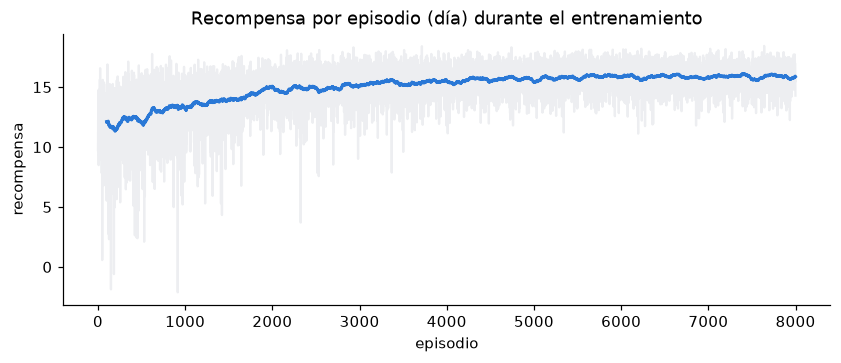

Recompensa media: primeros 200 episodios 11.76 → últimos 200 15.88


In [8]:
obs = {i: ver(TASK[i]["prompt"]) for i in meta}              # percepción ajustada solo con train
agent, curva = entrenar(train_ids, LAM, MU, GAMMA, 0, obs)
suav = pd.Series(curva).rolling(100).mean()
plt.figure(figsize=(9, 3.2)); plt.plot(curva, alpha=.15, color="#8a93a3"); plt.plot(suav, color="#2a78d6", lw=2)
plt.title("Recompensa por episodio (día) durante el entrenamiento"); plt.xlabel("episodio"); plt.ylabel("recompensa"); plt.show()
print(f"Recompensa media: primeros 200 episodios {np.mean(curva[:200]):.2f} → últimos 200 {np.mean(curva[-200:]):.2f}")

## 6. Evaluación en test, de punta a punta

200 días armados **solo con tareas de test**, los mismos para todas las estrategias. Todas deciden con la percepción, incluida la línea base "nube salvo privado".

In [9]:
test_dias = dias(test_ids, n=200, seed=123)
env_test = make_env(test_ids, 99, LAM, MU, obs)
res = pd.DataFrame(compare(agent, env_test, test_dias)).T
cols = ["calidad media", "calidad vs. nube segura", "% nube", "costo/día (USD)", "latencia media (s)", "fugas privadas", "sin presupuesto"]
res[cols].round(3)

,calidad media,calidad vs. nube segura,% nube,costo/día (USD),latencia media (s),fugas privadas,sin presupuesto
Q-learning (JARVIS),0.979,1.020,0.420,0.000,9.466,0.0,0.0
Nube salvo privado,0.960,1.000,0.692,0.001,6.258,0.0,842.0
Siempre nube (gemini),0.948,0.987,0.737,0.001,5.955,390.0,1051.0
Siempre local,0.748,0.779,0.000,0.000,9.620,0.0,0.0
Aleatoria,0.872,0.908,0.488,0.001,6.950,187.0,96.0
Regla manual,0.855,0.891,0.349,0.001,6.994,0.0,147.0


### Robustez: 10 semillas

Un solo entrenamiento puede tener suerte. Entreno 10 agentes con semillas distintas (mismos hiperparámetros) y exijo el criterio **en el peor caso**, no solo en promedio.

In [10]:
filas = []
for seed in range(10):
    ag, _ = entrenar(train_ids, LAM, MU, GAMMA, seed, obs)
    r = compare(ag, env_test, test_dias)["Q-learning (JARVIS)"]
    filas.append({"semilla": seed, **{k: r[k] for k in ["calidad vs. nube segura", "% nube", "fugas privadas"]}})
sem = pd.DataFrame(filas).set_index("semilla")
peor = {"calidad vs. nube segura": sem["calidad vs. nube segura"].min(), "% nube": sem["% nube"].max(),
        "fugas privadas": sem["fugas privadas"].max()}
sem.agg(["mean", "std", "min", "max"]).round(3)

,calidad vs. nube segura,% nube,fugas privadas
mean,1.02,0.42,0.0
std,0.00,0.00,0.0
min,1.02,0.42,0.0
max,1.02,0.42,0.0


In [11]:
print("Criterio en el PEOR de 10 entrenamientos:")
for c, v in check(peor).items(): print(("✅" if v else "❌"), c)
q = res.loc["Q-learning (JARVIS)"]
print(f"\nAgente principal: calidad {q['calidad vs. nube segura']:.1%} de la nube segura "
      f"({q['calidad media'] / res.loc['Siempre nube (gemini)', 'calidad media']:.1%} de la nube sin filtro), "
      f"nube en el {q['% nube']:.0%} de las peticiones, costo/día ${q['costo/día (USD)']:.5f} "
      f"vs ${res.loc['Nube salvo privado', 'costo/día (USD)']:.5f}, fugas {int(q['fugas privadas'])}.")

Criterio en el PEOR de 10 entrenamientos:
✅ Calidad ≥ 95 % de 'nube salvo privado'
✅ Uso de nube ≤ 60 % (ahorro ≥ 40 %)
✅ 0 fugas de datos privados

Agente principal: calidad 102.0% de la nube segura (103.3% de la nube sin filtro), nube en el 42% de las peticiones, costo/día $0.00028 vs $0.00110, fugas 0.


### ¿Cuánto cuesta equivocarse al percibir? (ablación)

Mismo protocolo, pero el agente ve las **etiquetas reales** (percepción perfecta). La diferencia mide cuánto pierde el router por los errores del Naive Bayes, el árbol y el detector.

In [12]:
agent_or, _ = entrenar(train_ids, LAM, MU, GAMMA, 0, None)
res_or = pd.DataFrame(compare(agent_or, make_env(test_ids, 99, LAM, MU, None), test_dias)).T
abl = pd.DataFrame({"percepción real (NB + árbol + detector)": res.loc["Q-learning (JARVIS)", cols[:3] + ["fugas privadas"]],
                    "percepción perfecta (oráculo)": res_or.loc["Q-learning (JARVIS)", cols[:3] + ["fugas privadas"]]}).T
abl.round(3)

,calidad media,calidad vs. nube segura,% nube,fugas privadas
percepción real (NB + árbol + detector),0.979,1.02,0.42,0.0
percepción perfecta (oráculo),0.979,1.02,0.47,0.0


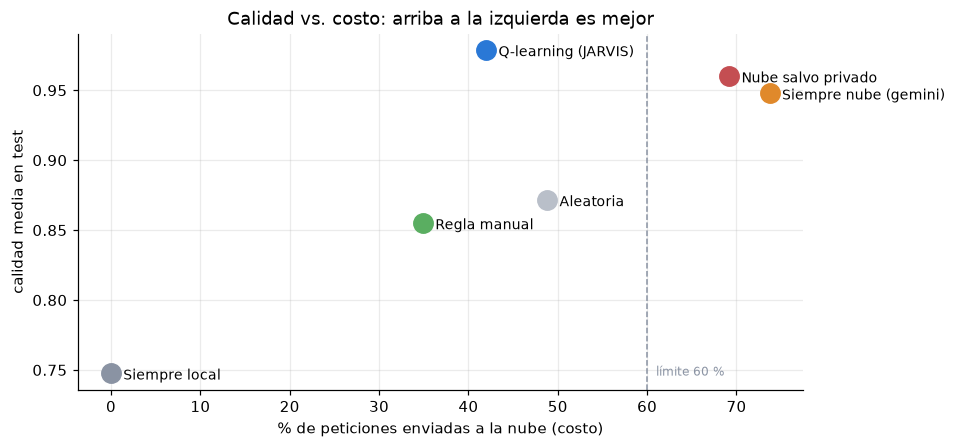

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
colores = {"Q-learning (JARVIS)": "#2a78d6", "Nube salvo privado": "#c44e52", "Siempre nube (gemini)": "#e0892b", "Siempre local": "#8a93a3",
           "Aleatoria": "#b9bfc9", "Regla manual": "#5aae61"}
for k, r in res.iterrows():
    ax.scatter(r["% nube"] * 100, r["calidad media"], s=160, color=colores[k], zorder=3)
    ax.annotate(k, (r["% nube"] * 100, r["calidad media"]), textcoords="offset points", xytext=(8, -4), fontsize=9)
ax.errorbar(sem["% nube"].mean() * 100, q["calidad media"], xerr=sem["% nube"].std() * 100, fmt="none", color="#2a78d6", alpha=.6)
ax.axvline(60, ls="--", color="#8a93a3", lw=1); ax.text(61, ax.get_ylim()[0] + .01, "límite 60 %", fontsize=8, color="#8a93a3")
ax.set_xlabel("% de peticiones enviadas a la nube (costo)"); ax.set_ylabel("calidad media en test")
ax.set_title("Calidad vs. costo: arriba a la izquierda es mejor"); ax.grid(alpha=.25); plt.show()

## 7. ¿Qué aprendió? La política

Acción preferida cuando hay presupuesto de sobra (nivel "alto"), por categoría y dificultad:

In [14]:
filas = []
for c in sorted({m["category"] for m in meta.values()}):
    for d in ["easy", "hard"]:
        priv = c == "privado"
        s = (c, d, priv, "alto")
        qv = agent.values(s)
        filas.append({"categoría": c, "dificultad": d, "privada": priv, "acción": max(agent.legal(s), key=qv.get),
                      "Q(local)": round(qv["local"], 2), "Q(gemini)": round(qv["gemini"], 2), "visitado": s in agent.Q})
politica = pd.DataFrame(filas); politica

,categoría,dificultad,privada,acción,Q(local),Q(gemini),visitado
0,codigo,easy,False,local,1.20,0.37,False
1,codigo,hard,False,local,1.34,0.92,True
2,extraccion,easy,False,local,1.53,1.40,True
3,extraccion,hard,False,local,1.61,1.28,True
4,formato,easy,False,local,1.70,1.66,True
5,formato,hard,False,local,1.63,1.51,True
6,hechos,easy,False,local,1.70,1.59,True
7,hechos,hard,False,local,1.63,1.60,True
8,matematicas,easy,False,gemini,1.22,1.63,True
9,matematicas,hard,False,gemini,0.68,1.51,True


In [15]:
acc = {r["categoría"] + "|" + r["dificultad"]: r["acción"] for _, r in politica.iterrows()}
print("Va a la nube:", ", ".join(sorted(k for k, v in acc.items() if v == "gemini")))
print("Se queda en local:", ", ".join(sorted(k for k, v in acc.items() if v == "local")))

Va a la nube: matematicas|easy, matematicas|hard
Se queda en local: codigo|easy, codigo|hard, extraccion|easy, extraccion|hard, formato|easy, formato|hard, hechos|easy, hechos|hard, privado|easy, privado|hard


**Interpretación.** El router aprende solo, a partir de recompensas, dónde la nube vale lo que cuesta: en las celdas donde el modelo local falla (sobre todo matemáticas) paga la nube; donde el local empata, se queda en local. Lo privado siempre se queda en local por el escudo. Con poco presupuesto se vuelve más conservador.

## 8. Banco oculto: 42 tareas nuevas, una sola evaluación

`bench/hidden_tasks.jsonl` tiene 42 tareas que **no se usaron para entrenar ni para elegir nada**: redacciones nuevas, funciones de código nuevas, hechos nuevos, datos privados nuevos y un tercio **en inglés** (JARVIS es bilingüe). Sus calificadores están validados con referencias y contraejemplos (`tests/test_hidden.py`).

El router que se despliega en JARVIS se entrena con **todo** el banco público (percepción incluida), con los hiperparámetros elegidos arriba, y se congela en `data/q_router.json`. Después, `bench/evaluar_router.py` lo evalúa sobre el banco oculto sin reentrenar nada.

> **Transparencia.** Al construir el banco oculto revisé una vez qué detectaba la percepción y encontré un hueco real de seguridad: el detector reconocía *my salary* pero no *mi salario*. Lo corregí (junto con otros patrones de finanzas personales en español) porque JARVIS en vivo lo necesita. Por eso, para una prueba totalmente ciega, `bench/evaluar_router.py` acepta cualquier banco nuevo con el mismo formato:
> ```
> python -m bench.run_bench --tareas sus_tareas.jsonl --salida data/sus_resultados.jsonl local gemini
> python -m bench.evaluar_router sus_tareas.jsonl data/sus_resultados.jsonl
> ```

In [16]:
ver_full = Perception(tasks)
obs_full = {i: ver_full(TASK[i]["prompt"]) for i in meta}
final, _ = entrenar(list(meta), LAM, MU, GAMMA, 0, obs_full)
final.save(ROOT / "data" / "q_router.json", config={"budget": BUDGET, "lam": LAM, "mu": MU, "gamma": GAMMA,
                                                    "entrenado_con": "banco público completo (86 tareas)"})
print("Router congelado en data/q_router.json → JARVIS en vivo lo usa automáticamente.\n")

from bench.evaluar_router import main as evaluar_oculto
hidden = pd.DataFrame(map(json.loads, open(ROOT / "data" / "hidden_results.jsonl")))
hidden = hidden[hidden.error.isna()]
print("Nota media por cerebro en el banco oculto:", hidden.groupby("brain").score.mean().round(3).to_dict(),
      "· modelos:", sorted(hidden["model"].dropna().unique()), "\n")
cumple_oculto = evaluar_oculto(ROOT / "bench" / "hidden_tasks.jsonl", ROOT / "data" / "hidden_results.jsonl")

Router congelado en data/q_router.json → JARVIS en vivo lo usa automáticamente.

Nota media por cerebro en el banco oculto: {'local': 0.762} · modelos: ['qwen3:4b-instruct-2507-q4_K_M'] 

No hay tareas con resultados de todos los cerebros todavía.


## 9. Conclusiones y siguiente paso (Parte 2)

- El router combina **cuatro técnicas de la Parte 1** (Naive Bayes, árbol de decisión, MDP y Q-learning) sobre **datos reales** de dos cerebros y se evalúa de punta a punta: la percepción puede equivocarse y ese error se paga en la evaluación.
- La comparación justa es contra "nube salvo privado": "siempre nube" parece fuerte, pero saca datos privados y se queda sin presupuesto, así que no es una opción real.
- El criterio se exige en el **peor de 10 entrenamientos**, y el router congelado se mide además en un **banco oculto** de 42 tareas nuevas, en parte en inglés.
- En JARVIS, este router decide **quién entra al consejo de cerebros**: si la petición es privada, solo delibera el local; si no, deliberan los cerebros de nube sanos y el más capaz sintetiza una sola respuesta. El nivel de presupuesto en vivo sale del gasto real del día.
- **Limitaciones:** hoy solo dos cerebros tienen datos (los de pago no tienen saldo), el banco es pequeño (86 + 42 tareas), el espacio de estados es tabular y la dificultad se estima con una sola variable (la longitud).
- **Parte 2:** reemplazar la Q-table por una red neuronal sobre *embeddings* de la petición (sem. 9–10), evaluar zero/few-shot/CoT por cerebro (sem. 11) y darle a JARVIS memoria RAG y herramientas (sem. 12–13).